# Hourly Shift Model 90-Day Impact

This notebook reuses the shared `hourly_shift_model_v2.py` setup, simulates the current hourly shift model across a non-overlapping 90-day period, and visualizes baseline versus shifted household consumption.

In [146]:
from copy import deepcopy

import matplotlib.pyplot as plt
import pandas as pd

from archive.hourly_shift_model_v2 import (
    DECISION_WEIGHTS,
    FORECAST_HORIZON_HOURS,
    HOUSEHOLD_SHARE_OF_SYSTEM,
    SEGMENT_ASSUMPTIONS,
    assemble_window_for_issue_time,
    build_historical_segment_capacity,
    build_issue_catalog,
    build_shift_plan,
    load_predictions,
    load_system_load,
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

In [147]:
SIMULATION_DAYS = 90
NON_OVERLAPPING_WINDOW_DAYS = 5
SIMULATION_WINDOWS = SIMULATION_DAYS // NON_OVERLAPPING_WINDOW_DAYS

preds = load_predictions()
system_load = load_system_load()
issue_catalog = build_issue_catalog(preds)
daily_issue_times = issue_catalog.loc[
    issue_catalog["issue_time"].dt.hour == 12,
    "issue_time",
].reset_index(drop=True)

simulation_daily_issue_times = daily_issue_times.tail(SIMULATION_DAYS).reset_index(drop=True)
simulation_issue_times = simulation_daily_issue_times.iloc[::NON_OVERLAPPING_WINDOW_DAYS].reset_index(drop=True)

if len(simulation_issue_times) != SIMULATION_WINDOWS:
    raise ValueError(
        f"Expected {SIMULATION_WINDOWS} windows for {SIMULATION_DAYS} days, found {len(simulation_issue_times)}."
    )

display(
    pd.Series(
        {
            "simulation_days": SIMULATION_DAYS,
            "window_stride_days": NON_OVERLAPPING_WINDOW_DAYS,
            "simulation_windows": int(len(simulation_issue_times)),
            "simulated_hours": int(len(simulation_issue_times) * FORECAST_HORIZON_HOURS),
            "start_issue_time": simulation_issue_times.iloc[0],
            "end_issue_time": simulation_issue_times.iloc[-1],
        }
    ).to_frame("value")
)

,value
simulation_days,90
window_stride_days,5
simulation_windows,18
simulated_hours,2160
start_issue_time,2026-01-03 12:00:00
end_issue_time,2026-04-03 12:00:00


In [148]:
segment_assumptions = deepcopy(SEGMENT_ASSUMPTIONS)
historical_segment_capacity = build_historical_segment_capacity(
    system_load=system_load,
    segment_assumptions=segment_assumptions,
    household_share_of_system=HOUSEHOLD_SHARE_OF_SYSTEM,
)

scenario_profiles = []
total_shifted_energy_mwh = 0.0
total_shift_events = 0

for issue_time in simulation_issue_times:
    window_df = assemble_window_for_issue_time(
        issue_time=issue_time,
        preds=preds,
        system_load=system_load,
        household_share_of_system=HOUSEHOLD_SHARE_OF_SYSTEM,
        segment_assumptions=segment_assumptions,
    )
    profile_df, shifts_df = build_shift_plan(
        window_df=window_df,
        segment_assumptions=segment_assumptions,
        decision_weights=DECISION_WEIGHTS,
        historical_segment_capacity=historical_segment_capacity,
    )
    profile_df = profile_df.copy()
    profile_df["issue_time"] = pd.Timestamp(issue_time)
    scenario_profiles.append(profile_df)

    if not shifts_df.empty:
        total_shifted_energy_mwh += float(shifts_df["shift_mwh"].sum())
        total_shift_events += int(len(shifts_df))

simulation_profiles_df = (
    pd.concat(scenario_profiles, ignore_index=True)
    .sort_values("target_time")
    .drop_duplicates(subset=["target_time"], keep="first")
    .reset_index(drop=True)
)
simulation_profiles_df["impact_mwh"] = (
    simulation_profiles_df["household_load_mwh"] - simulation_profiles_df["shifted_household_load_mwh"]
)

display(
    pd.Series(
        {
            "simulation_start": simulation_profiles_df["target_time"].min(),
            "simulation_end": simulation_profiles_df["target_time"].max(),
            "hours_in_plot": int(len(simulation_profiles_df)),
            "total_shift_events": total_shift_events,
            "total_shifted_energy_mwh": round(total_shifted_energy_mwh, 2),
            "avg_impact_mwh": round(simulation_profiles_df["impact_mwh"].abs().mean(), 4),
        }
    ).to_frame("value")
)

display(
    simulation_profiles_df[
        [
            "target_time",
            "household_load_mwh",
            "shifted_household_load_mwh",
            "impact_mwh",
        ]
    ].head()
)

,value
simulation_start,2026-01-03 13:00:00
simulation_end,2026-04-08 12:00:00
hours_in_plot,2160
total_shift_events,3020
total_shifted_energy_mwh,32124.85
avg_impact_mwh,24.5626


,target_time,household_load_mwh,shifted_household_load_mwh,impact_mwh
0,2026-01-03 13:00:00,999.457891,849.539208,149.918684
1,2026-01-03 14:00:00,997.220981,850.735070,146.485911
2,2026-01-03 15:00:00,1003.974568,870.237236,133.737332
3,2026-01-03 16:00:00,1042.447616,980.505046,61.942570
4,2026-01-03 17:00:00,1096.984420,1020.644530,76.339889


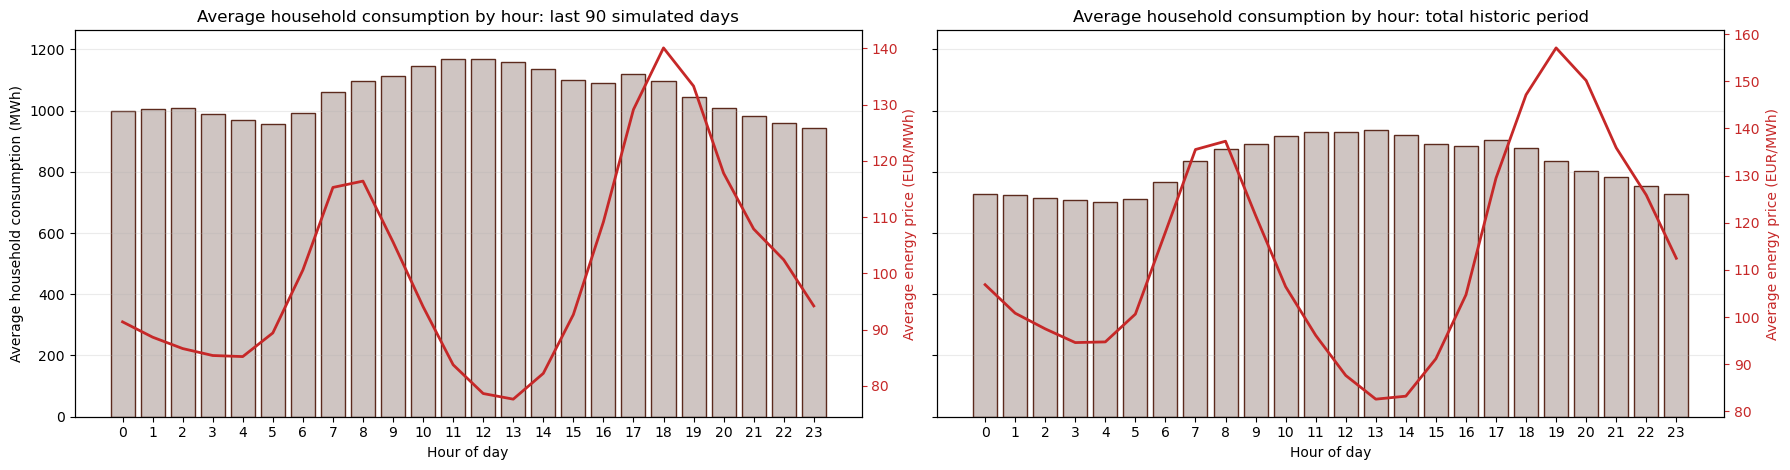

In [155]:
last90_hourly_profile = simulation_profiles_df.copy()
last90_hourly_profile["hour"] = last90_hourly_profile["target_time"].dt.hour
last90_avg_by_hour = (
    last90_hourly_profile.groupby("hour", as_index=False)["household_load_mwh"]
    .mean()
    .sort_values("hour")
)
last90_price_by_hour = (
    last90_hourly_profile.groupby("hour", as_index=False)["DayAheadPriceEUR"]
    .mean()
    .sort_values("hour")
)

historic_household_profile = system_load.copy()
historic_household_profile["hour"] = historic_household_profile["target_time"].dt.hour
historic_household_profile["household_load_mwh"] = (
    historic_household_profile["system_load_mwh"] * HOUSEHOLD_SHARE_OF_SYSTEM
)
historic_avg_by_hour = (
    historic_household_profile.groupby("hour", as_index=False)["household_load_mwh"]
    .mean()
    .sort_values("hour")
)

historic_price_profile = (
    preds[["target_time", "DayAheadPriceEUR"]]
    .drop_duplicates(subset=["target_time"])
    .sort_values("target_time")
    .reset_index(drop=True)
)
historic_price_profile["hour"] = historic_price_profile["target_time"].dt.hour
historic_price_by_hour = (
    historic_price_profile.groupby("hour", as_index=False)["DayAheadPriceEUR"]
    .mean()
    .sort_values("hour")
)

ymax = max(
    float(last90_avg_by_hour["household_load_mwh"].max()),
    float(historic_avg_by_hour["household_load_mwh"].max()),
)

fig, axes = plt.subplots(1, 2, figsize=(18, 4.8), sharey=True)

axes[0].bar(
    last90_avg_by_hour["hour"],
    last90_avg_by_hour["household_load_mwh"],
    color="#CFC5C2",
    edgecolor="#5C2A1D",
)
axes[0].set_title("Average household consumption by hour: last 90 simulated days")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Average household consumption (MWh)")
axes[0].set_xticks(range(24))
axes[0].set_ylim(0, ymax * 1.08)
axes[0].grid(axis="y", alpha=0.25)
ax0_price = axes[0].twinx()
ax0_price.plot(
    last90_price_by_hour["hour"],
    last90_price_by_hour["DayAheadPriceEUR"],
    color="#C62828",
    linewidth=2.0,
)
ax0_price.set_ylabel("Average energy price (EUR/MWh)", color="#C62828")
ax0_price.tick_params(axis="y", colors="#C62828")

axes[1].bar(
    historic_avg_by_hour["hour"],
    historic_avg_by_hour["household_load_mwh"],
    color="#CFC5C2",
    edgecolor="#5C2A1D",
)
axes[1].set_title("Average household consumption by hour: total historic period")
axes[1].set_xlabel("Hour of day")
axes[1].set_xticks(range(24))
axes[1].set_ylim(0, ymax * 1.08)
axes[1].grid(axis="y", alpha=0.25)
ax1_price = axes[1].twinx()
ax1_price.plot(
    historic_price_by_hour["hour"],
    historic_price_by_hour["DayAheadPriceEUR"],
    color="#C62828",
    linewidth=2.0,
)
ax1_price.set_ylabel("Average energy price (EUR/MWh)", color="#C62828")
ax1_price.tick_params(axis="y", colors="#C62828")

fig.tight_layout()

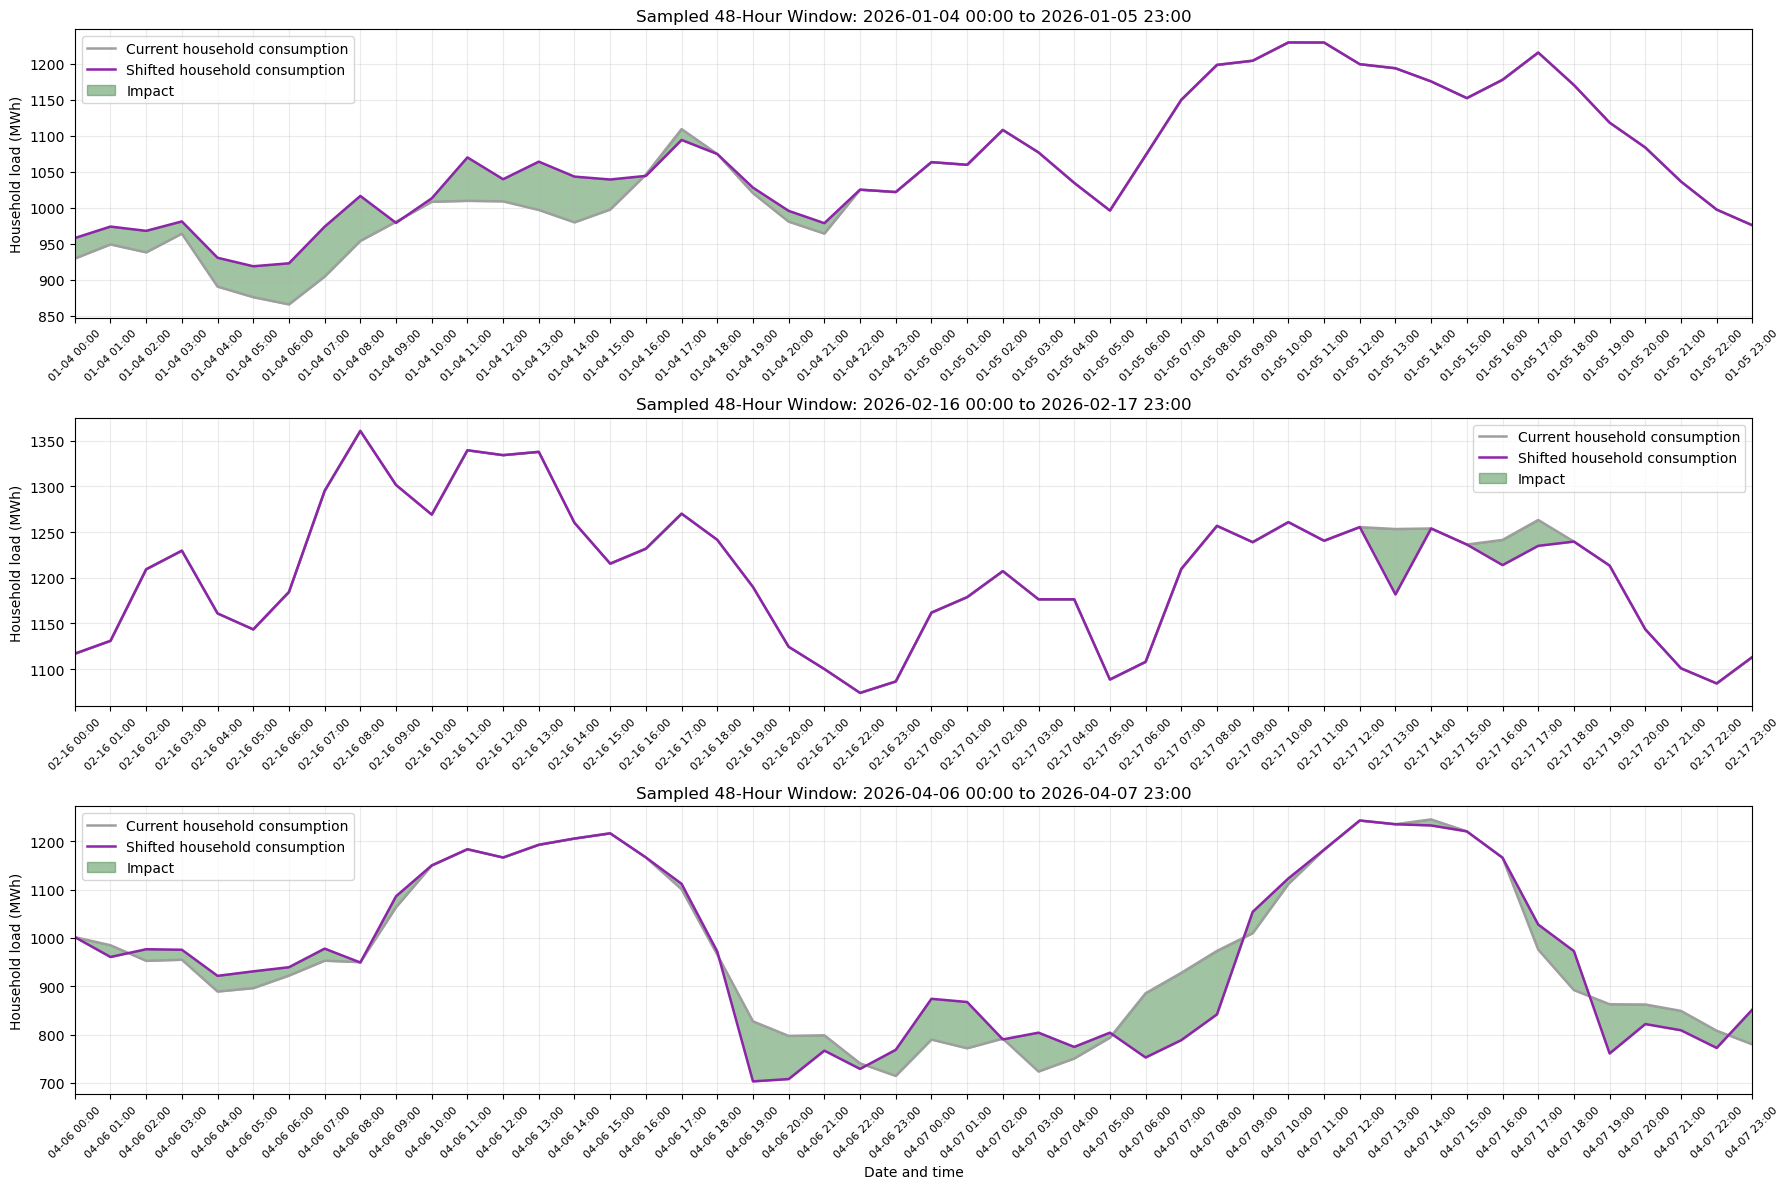

In [150]:
import matplotlib.dates as mdates

sample_plot_df = simulation_profiles_df.copy()
day_counts = (
    sample_plot_df.assign(day=sample_plot_df["target_time"].dt.normalize())
    .groupby("day")
    .size()
    .reset_index(name="n_hours")
)
full_days = day_counts.loc[day_counts["n_hours"] == 24, "day"].reset_index(drop=True)
valid_window_starts = full_days[
    full_days.shift(-1) == (full_days + pd.Timedelta(days=1))
].reset_index(drop=True)

if len(valid_window_starts) < 3:
    raise ValueError(f"Expected at least 3 full 48-hour windows, found {len(valid_window_starts)}.")

sampled_window_positions = [0, len(valid_window_starts) // 2, len(valid_window_starts) - 1]
sampled_window_starts = valid_window_starts.iloc[sampled_window_positions].tolist()
impact_color = "#2E7D32"

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharey=False)

for ax, window_start in zip(axes, sampled_window_starts):
    window_start = pd.Timestamp(window_start)
    window_end = window_start + pd.Timedelta(hours=47)
    window_df = sample_plot_df.loc[
        (sample_plot_df["target_time"] >= window_start)
        & (sample_plot_df["target_time"] <= window_end)
    ].copy()

    ax.plot(
        window_df["target_time"],
        window_df["household_load_mwh"],
        color="#9E9E9E",
        linewidth=1.8,
        label="Current household consumption",
    )
    ax.plot(
        window_df["target_time"],
        window_df["shifted_household_load_mwh"],
        color="#8E24AA",
        linewidth=1.8,
        label="Shifted household consumption",
    )
    ax.fill_between(
        window_df["target_time"],
        window_df["household_load_mwh"],
        window_df["shifted_household_load_mwh"],
        color=impact_color,
        alpha=0.45,
        label="Impact",
    )
    ax.set_title(
        f"Sampled 48-Hour Window: {window_start:%Y-%m-%d %H:%M} to {window_end:%Y-%m-%d %H:%M}"
    )
    ax.set_ylabel("Household load (MWh)")
    ax.set_xlim(window_start, window_end)
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.grid(alpha=0.25)
    ax.legend()

axes[-1].set_xlabel("Date and time")
plt.tight_layout()

C:\Users\rebec\AppData\Local\Temp\ipykernel_11588\1558610543.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.965, 1])


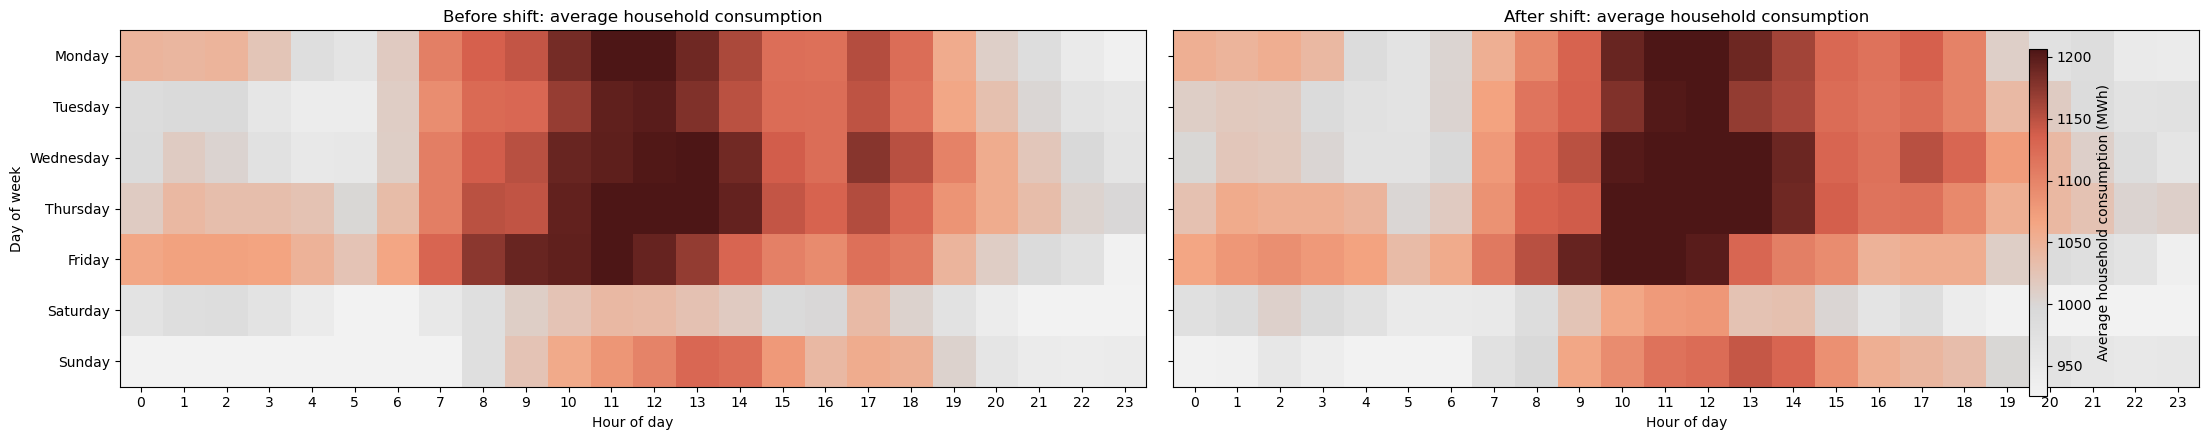

In [151]:
from matplotlib.colors import LinearSegmentedColormap

required_cols = [
    "target_time",
    "household_load_mwh",
    "shifted_household_load_mwh",
    "system_load_mwh",
    "shifted_system_load_mwh",
]
flexible_segments = [
    segment
    for segment, params in segment_assumptions.items()
    if float(params["max_shiftable_share"]) > 0
]
baseline_flexible_cols = [f"{segment}_baseline_mwh" for segment in flexible_segments]
shifted_flexible_cols = [f"{segment}_shifted_mwh" for segment in flexible_segments]
required_cols = required_cols + baseline_flexible_cols + shifted_flexible_cols
missing_cols = [col for col in required_cols if col not in simulation_profiles_df.columns]
if missing_cols:
    raise KeyError(
        "simulation_profiles_df is missing required columns for the before/after heatmaps: "
        + ", ".join(missing_cols)
    )

dow_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

heatmap_plot_df = simulation_profiles_df.copy()
heatmap_plot_df["hour"] = heatmap_plot_df["target_time"].dt.hour
heatmap_plot_df["day_of_week"] = pd.Categorical(
    heatmap_plot_df["target_time"].dt.day_name(),
    categories=dow_order,
    ordered=True,
)

heatmap_plot_df["baseline_total_flexible_mwh"] = heatmap_plot_df[baseline_flexible_cols].sum(axis=1)
heatmap_plot_df["shifted_total_flexible_mwh"] = heatmap_plot_df[shifted_flexible_cols].sum(axis=1)

grey_to_darkred = LinearSegmentedColormap.from_list(
    "grey_to_darkred",
    ["#F2F2F2", "#D9D9D9", "#F4A582", "#D6604D", "#4D1616"],
)

def plot_before_after_heatmaps(
    plot_df: pd.DataFrame,
    before_col: str,
    after_col: str,
    before_title: str,
    after_title: str,
    colorbar_label: str,
) -> None:
    before_heatmap = (
        plot_df.groupby(["day_of_week", "hour"], as_index=False, observed=False)[before_col]
        .mean()
        .sort_values(["day_of_week", "hour"])
        .pivot(index="day_of_week", columns="hour", values=before_col)
    )

    after_heatmap = (
        plot_df.groupby(["day_of_week", "hour"], as_index=False, observed=False)[after_col]
        .mean()
        .sort_values(["day_of_week", "hour"])
        .pivot(index="day_of_week", columns="hour", values=after_col)
    )

    combined_values = pd.concat(
        [before_heatmap.stack(), after_heatmap.stack()],
        ignore_index=True,
    )
    color_min = float(combined_values.quantile(0.05))
    color_max = float(combined_values.quantile(0.95))

    if color_max <= color_min:
        color_min = float(combined_values.min())
        color_max = float(combined_values.max())

    fig, axes = plt.subplots(1, 2, figsize=(23, 4.5), sharey=True)

    for ax, heatmap_df, title in zip(
        axes,
        [before_heatmap, after_heatmap],
        [before_title, after_title],
    ):
        im = ax.imshow(
            heatmap_df.to_numpy(),
            aspect="auto",
            cmap=grey_to_darkred,
            interpolation="nearest",
            vmin=color_min,
            vmax=color_max,
        )
        ax.set_title(title)
        ax.set_xlabel("Hour of day")
        ax.set_xticks(range(24))

    axes[0].set_ylabel("Day of week")
    axes[0].set_yticks(range(len(before_heatmap.index)))
    axes[0].set_yticklabels(before_heatmap.index.tolist())
    axes[1].set_yticks(range(len(after_heatmap.index)))
    axes[1].set_yticklabels(after_heatmap.index.tolist())

    cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.025)
    cbar.set_label(colorbar_label)
    fig.tight_layout(rect=[0, 0, 0.965, 1])

plot_before_after_heatmaps(
    heatmap_plot_df,
    before_col="household_load_mwh",
    after_col="shifted_household_load_mwh",
    before_title="Before shift: average household consumption",
    after_title="After shift: average household consumption",
    colorbar_label="Average household consumption (MWh)",
)

C:\Users\rebec\AppData\Local\Temp\ipykernel_11588\1558610543.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.965, 1])


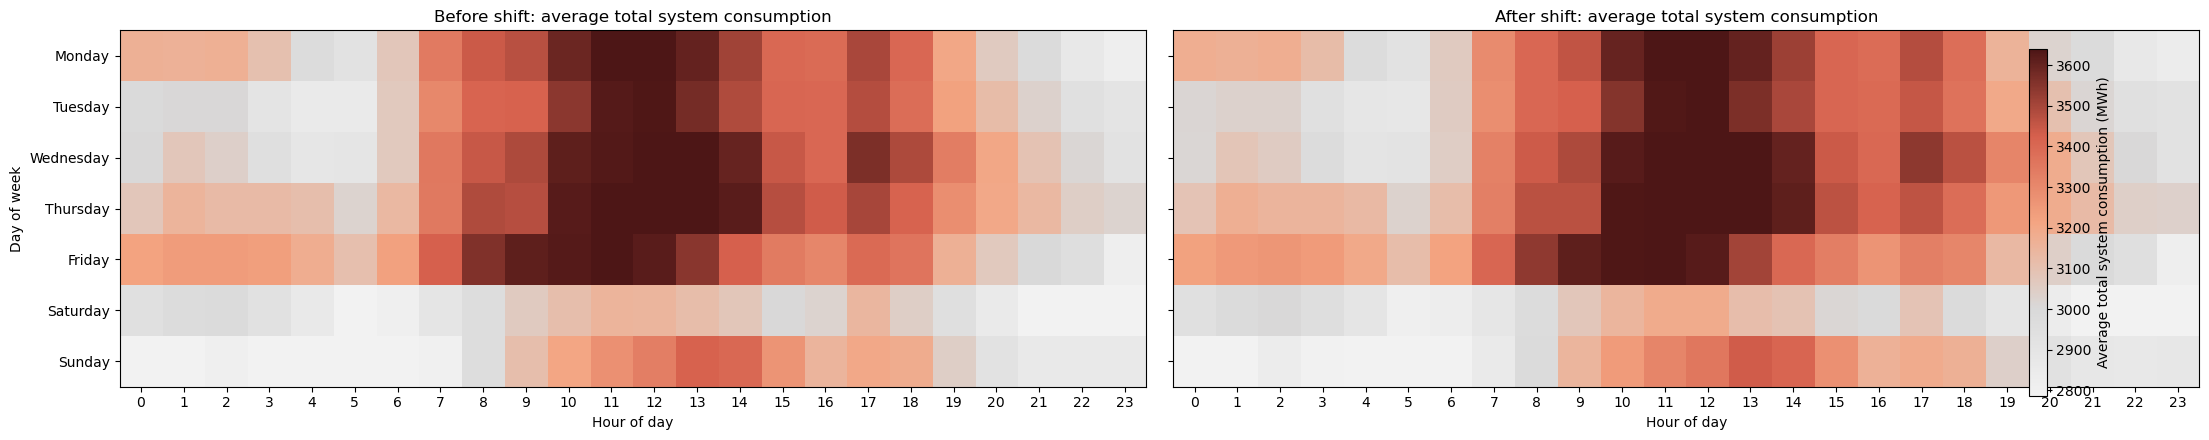

In [152]:
plot_before_after_heatmaps(
    heatmap_plot_df,
    before_col="system_load_mwh",
    after_col="shifted_system_load_mwh",
    before_title="Before shift: average total system consumption",
    after_title="After shift: average total system consumption",
    colorbar_label="Average total system consumption (MWh)",
)

C:\Users\rebec\AppData\Local\Temp\ipykernel_11588\1558610543.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.965, 1])


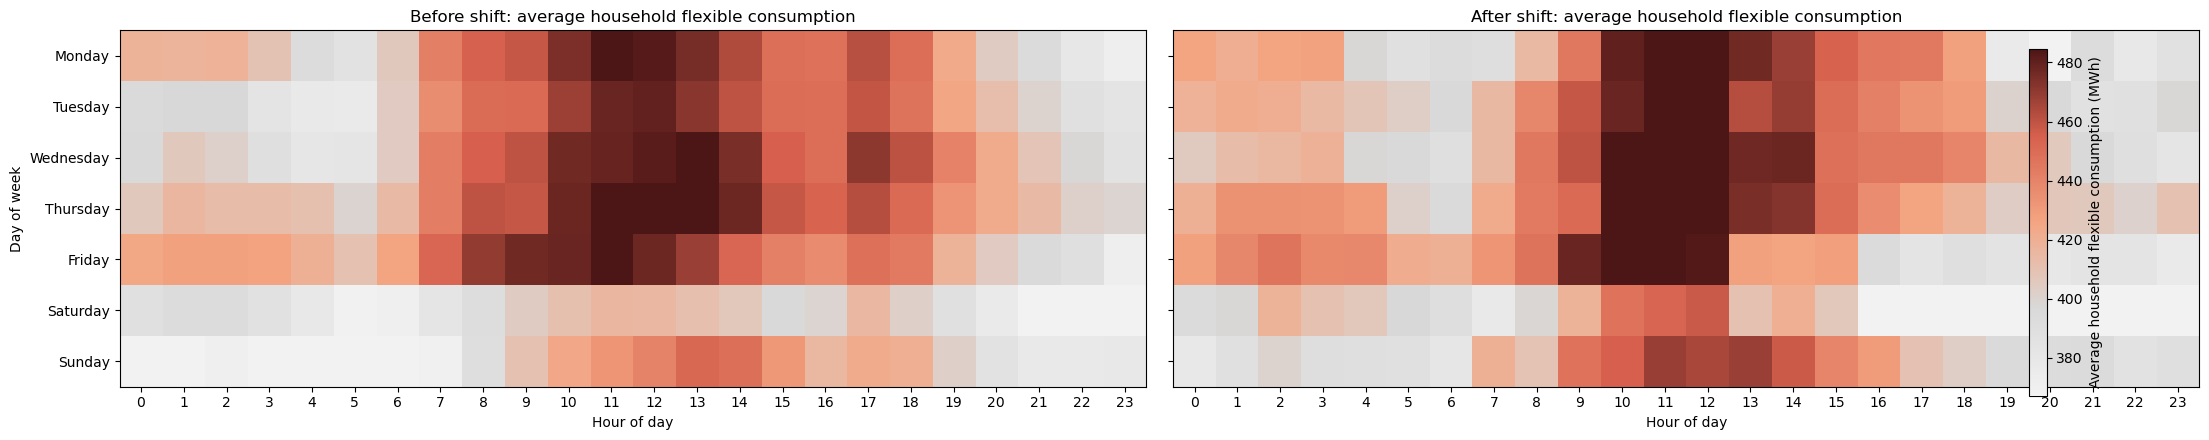

In [153]:
plot_before_after_heatmaps(
    heatmap_plot_df,
    before_col="baseline_total_flexible_mwh",
    after_col="shifted_total_flexible_mwh",
    before_title="Before shift: average household flexible consumption",
    after_title="After shift: average household flexible consumption",
    colorbar_label="Average household flexible consumption (MWh)",
)

,current_hours_above_p95,impact_hours,shifted_hours_above_p95,peak_hour_reduction_pct
case,,,,
Total household,877,4,873,0.46
Total system energy,877,2,875,0.23


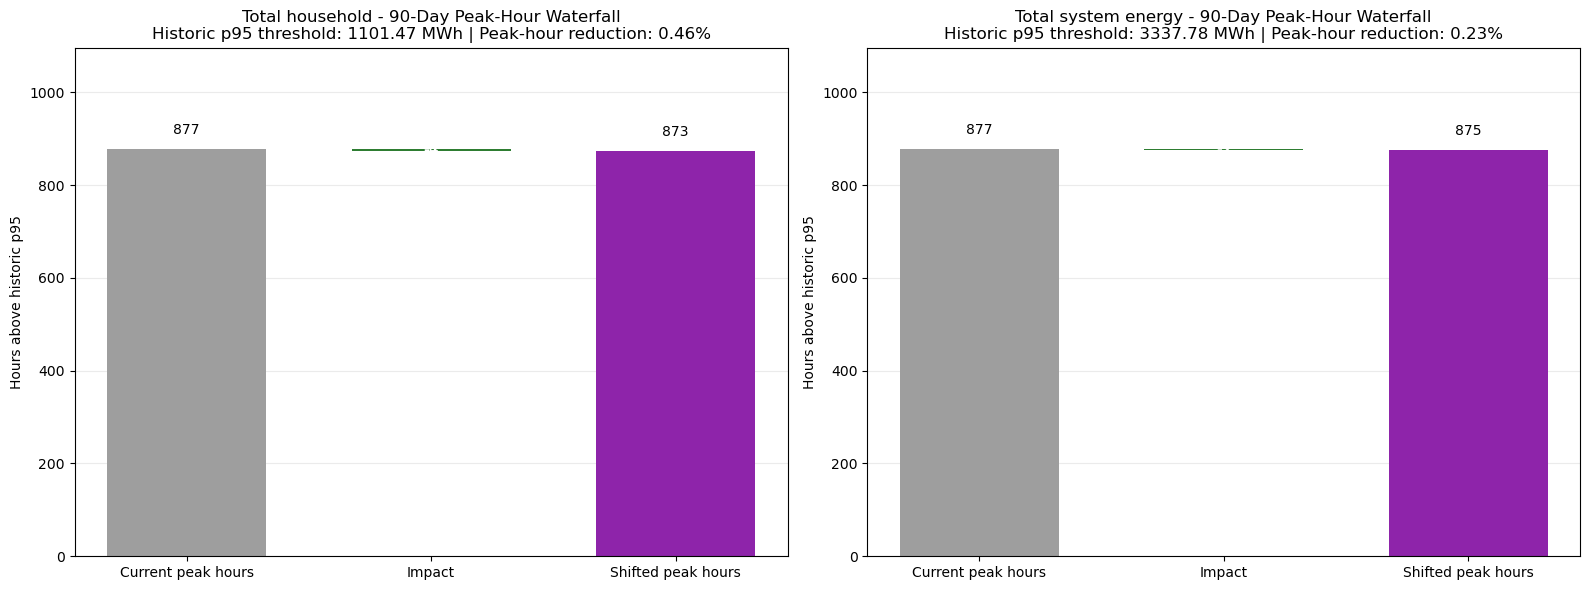

In [154]:
import matplotlib.pyplot as plt
import pandas as pd

if "peak_excess_summary_df" not in globals():
    required_cols = [
        "household_load_mwh",
        "shifted_household_load_mwh",
        "system_load_mwh",
        "shifted_system_load_mwh",
    ]
    missing_cols = [col for col in required_cols if col not in simulation_profiles_df.columns]
    if missing_cols:
        raise KeyError(
            "simulation_profiles_df is missing required columns for the peak-hour waterfall: "
            + ", ".join(missing_cols)
        )

    historic_p95_thresholds = {
        "Total household": float((system_load["system_load_mwh"] * HOUSEHOLD_SHARE_OF_SYSTEM).quantile(0.95)),
        "Total system energy": float(system_load["system_load_mwh"].quantile(0.95)),
    }

    def compute_peak_excess_summary(
        df: pd.DataFrame,
        baseline_col: str,
        shifted_col: str,
        label: str,
        baseline_p95: float,
    ) -> dict:
        current_excess = (df[baseline_col] - baseline_p95).clip(lower=0)
        shifted_excess = (df[shifted_col] - baseline_p95).clip(lower=0)
        current_total = float(current_excess.sum())
        shifted_total = float(shifted_excess.sum())
        impact_total = current_total - shifted_total
        reduction_pct = 100.0 * impact_total / current_total if current_total > 0 else 0.0
        return {
            "case": label,
            "baseline_p95_mwh": baseline_p95,
            "current_above_p95_mwh": current_total,
            "impact_mwh": impact_total,
            "shifted_above_p95_mwh": shifted_total,
            "peak_reduction_pct": reduction_pct,
            "current_hours_above_p95": int((df[baseline_col] > baseline_p95).sum()),
            "shifted_hours_above_p95": int((df[shifted_col] > baseline_p95).sum()),
        }

    peak_excess_summary_df = pd.DataFrame(
        [
            compute_peak_excess_summary(
                simulation_profiles_df,
                baseline_col="household_load_mwh",
                shifted_col="shifted_household_load_mwh",
                label="Total household",
                baseline_p95=historic_p95_thresholds["Total household"],
            ),
            compute_peak_excess_summary(
                simulation_profiles_df,
                baseline_col="system_load_mwh",
                shifted_col="shifted_system_load_mwh",
                label="Total system energy",
                baseline_p95=historic_p95_thresholds["Total system energy"],
            ),
        ]
    )

peak_excess_summary_df = peak_excess_summary_df.copy()
peak_excess_summary_df["impact_hours"] = (
    peak_excess_summary_df["current_hours_above_p95"]
    - peak_excess_summary_df["shifted_hours_above_p95"]
)
peak_excess_summary_df["peak_hour_reduction_pct"] = (
    100.0
    * peak_excess_summary_df["impact_hours"]
    / peak_excess_summary_df["current_hours_above_p95"].where(
        peak_excess_summary_df["current_hours_above_p95"] > 0,
        other=1,
    )
)

display(
    peak_excess_summary_df[
        [
            "case",
            "current_hours_above_p95",
            "impact_hours",
            "shifted_hours_above_p95",
            "peak_hour_reduction_pct",
        ]
    ]
    .assign(peak_hour_reduction_pct=lambda df: df["peak_hour_reduction_pct"].round(2))
    .set_index("case")
)

current_color = globals().get("current_color", "#9E9E9E")
shifted_color = globals().get("shifted_color", "#8E24AA")
impact_color = globals().get("impact_color", "#2E7D32")


def plot_peak_hours_waterfall(ax, row: pd.Series) -> None:
    current_hours = float(row["current_hours_above_p95"])
    impact_hours = float(row["impact_hours"])
    shifted_hours = float(row["shifted_hours_above_p95"])
    scale = max(current_hours, shifted_hours, 1.0)

    ax.bar(0, current_hours, width=0.65, color=current_color)
    ax.bar(1, -impact_hours, width=0.65, bottom=current_hours, color=impact_color)
    ax.bar(2, shifted_hours, width=0.65, color=shifted_color)

    ax.text(0, current_hours + scale * 0.03, f"{current_hours:.0f}", ha="center", va="bottom")
    ax.text(
        1,
        current_hours - impact_hours / 2,
        f"-{impact_hours:.0f}",
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
    )
    ax.text(2, shifted_hours + scale * 0.03, f"{shifted_hours:.0f}", ha="center", va="bottom")

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["Current peak hours", "Impact", "Shifted peak hours"])
    ax.set_ylabel("Hours above historic p95")
    ax.set_title(
        f"{row['case']} - 90-Day Peak-Hour Waterfall\nHistoric p95 threshold: {row['baseline_p95_mwh']:.2f} MWh | Peak-hour reduction: {row['peak_hour_reduction_pct']:.2f}%"
    )
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.set_ylim(0, scale * 1.25)


fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for ax, (_, row) in zip(axes, peak_excess_summary_df.iterrows()):
    plot_peak_hours_waterfall(ax, row)

plt.tight_layout()
